In [1]:
import os
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics
import subprocess
import sys
import seaborn as sns
import numpy as np
from scipy.sparse import csr_matrix
import scanpy.external as sce
from sklearn.metrics import silhouette_score
import datetime
import numpy as np
from collections import defaultdict
import scipy.sparse as sp
from collections import defaultdict
import gffutils 
import scipy.sparse as sp
import gffutils 
from scipy.stats import spearmanr, pearsonr
from scipy import stats

from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde
import statsmodels.api as sm
from scipy.optimize import minimize
from scipy.optimize import minimize

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from collections import defaultdict
import pandas as pd
import os
import gffutils
from tqdm import tqdm
from intervaltree import IntervalTree

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/GeneExpression


In [2]:
# Open the files 
WD="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/processed_data"

common_broad_types = ['MICROGLIA', "ENDOTHELIAL_CELL", "GLIAL_CELL", "PERICYTE"]
common_broad_types = ["GLIAL_CELL"]

# Make an empty list to store the dataframes
df_list = []

for cell in common_broad_types:
    print(f"Reading and processing pseudobulk raw counts for {cell}...")
    cell_type = pd.read_csv(f"{WD}/pseudobulk_{cell}.tsv", sep="\t")
    cell_type["gene_name"] = cell_type["gene"]
    cell_type = cell_type[(cell_type["mean_transcript_length"] > 0) & (cell_type["mean_intron_length"] > 0)]
    cell_type["cell_type"] = cell
    cell_type["norm_ex"] = cell_type["ab_exons_sum"]/cell_type["mean_transcript_length"] * np.median(cell_type["mean_transcript_length"])
    cell_type["norm_int"] = cell_type["ab_introns_sum"]/cell_type["mean_intron_length"] * np.median(cell_type["mean_intron_length"])
    cell_type["norm_ts"] = cell_type["ts_sum"]/cell_type["mean_transcript_length"] * np.median(cell_type["mean_transcript_length"])
    df_list.append(cell_type)

# Combine df_list into a single DataFrame
combined_df = pd.concat(df_list, ignore_index=True)

# Normalize length normalized values by library size (sum of all genes)
combined_df["norm_ex"] = combined_df["norm_ex"] / combined_df["norm_ex"].sum() * 10000
combined_df["norm_int"] = combined_df["norm_int"] / combined_df["norm_int"].sum() * 10000
combined_df["norm_ts"] = combined_df["norm_ts"] / combined_df["norm_ts"].sum() * 10000

# Apply log1p to the length normalized values 
combined_df["log_norm_ex"] = np.log1p(combined_df["norm_ex"])
combined_df["log_norm_int"] = np.log1p(combined_df["norm_int"])
combined_df["log_norm_ts"] = np.log1p(combined_df["norm_ts"])

# remove any lncRNA genes or retained intron genes 
print(f"Number of genes remaining: {len(combined_df)}")

Reading and processing pseudobulk raw counts for GLIAL_CELL...
Number of genes remaining: 19022


<Axes: >

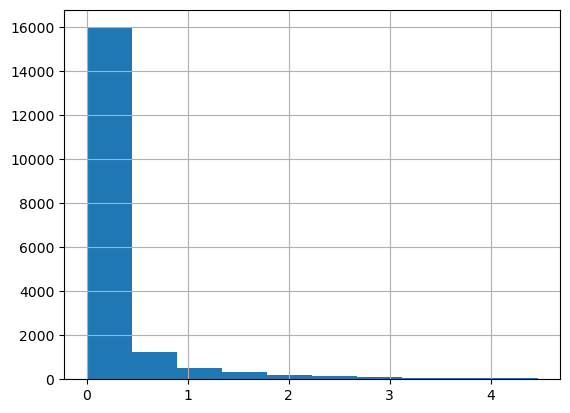

In [3]:
# remove combined_df values with norm_ex or norm_ts  that are outliers 
outlier_val = combined_df["norm_ex"].quantile(0.99)
combined_df = combined_df[combined_df["norm_ex"] < outlier_val]
outlier_val = combined_df["norm_ts"].quantile(0.99)
combined_df = combined_df[combined_df["norm_ts"] < outlier_val]

combined_df["norm_ts"].hist()

Linear Model Summary:
                            OLS Regression Results                            
Dep. Variable:            log_norm_ts   R-squared:                       0.684
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                 2.015e+04
Date:                Mon, 12 May 2025   Prob (F-statistic):               0.00
Time:                        14:42:45   Log-Likelihood:                 7512.2
No. Observations:               18642   AIC:                        -1.502e+04
Df Residuals:                   18639   BIC:                        -1.499e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0192      0.0

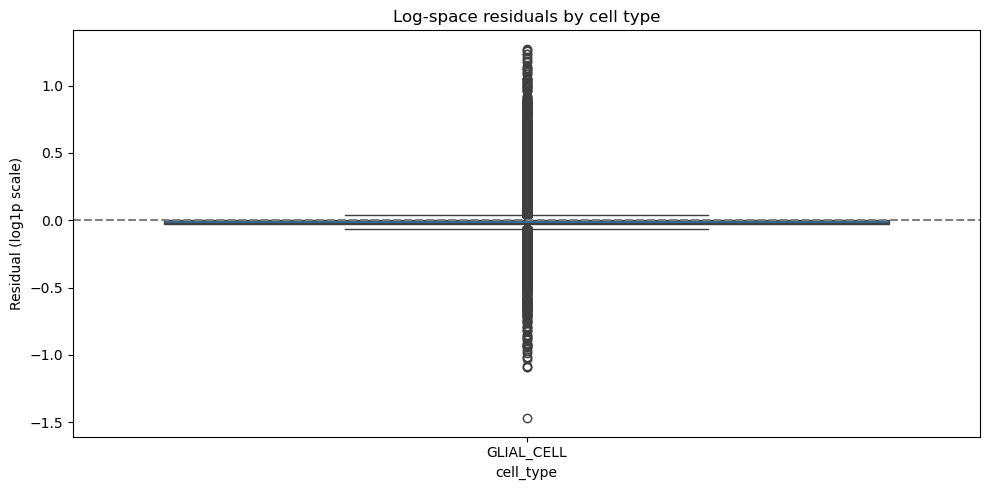

Saved model to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/GeneExpression/linear_norm_ts_model.pkl


In [4]:
# ---------------------------------------------------
# 1. Linear regression: y ~ B0e + B1i 
# ---------------------------------------------------

# Prepare the data
X_linear = pd.DataFrame({
    'exons': combined_df['log_norm_ex'],
    'introns': combined_df['log_norm_int']
})

# Prep cell type as categorical variable for X 
# X_linear = pd.get_dummies(X_linear, columns=['cell_type'], drop_first=True)
# if 'cell_type' in X_linear.columns:
#     X_linear = X_linear.drop(columns=['cell_type'])
X_linear = sm.add_constant(X_linear)  # Add intercept
y_linear = combined_df['log_norm_ts']

# Ensure both X and y are float dtype
X_linear = X_linear.astype(float)
y_linear = y_linear.astype(float)

# Fit the model
model_linear = sm.OLS(y_linear, X_linear).fit()
y_pred_linear = model_linear.predict(X_linear)

# Clip the predictions to avoid negative values? 
# y_pred_linear = np.clip(y_pred_linear, 0, None)

# Calculate metrics
r2_linear = model_linear.rsquared
rmse_linear = np.sqrt(np.mean((y_linear - y_pred_linear) ** 2))
combined_df["log_residual"] = y_linear - y_pred_linear
combined_df["linear_pred"] = y_pred_linear
print("Linear Model Summary:")
print(model_linear.summary())

plt.figure(figsize=(10, 5))
sns.boxplot(data=combined_df, x="cell_type", y="log_residual")
plt.axhline(0, linestyle='--', color='gray')
plt.ylabel("Residual (log1p scale)")
plt.title("Log-space residuals by cell type")
plt.tight_layout()
plt.show()

import pickle
output_dir=current_dir

# Save the model to a file
with open(f"{output_dir}/linear_log_norm_ts_model.pkl", "wb") as f:
    pickle.dump(model_linear, f)

# can use model_loaded.predict(X_linear) or model_loaded.summary()
print(f"Saved model to {output_dir}/linear_norm_ts_model.pkl")

Spearman correlation for GLIAL_CELL: 0.89 (p-value: 0.00e+00)
Pearson correlation for GLIAL_CELL: 0.83 (p-value: 0.00e+00)


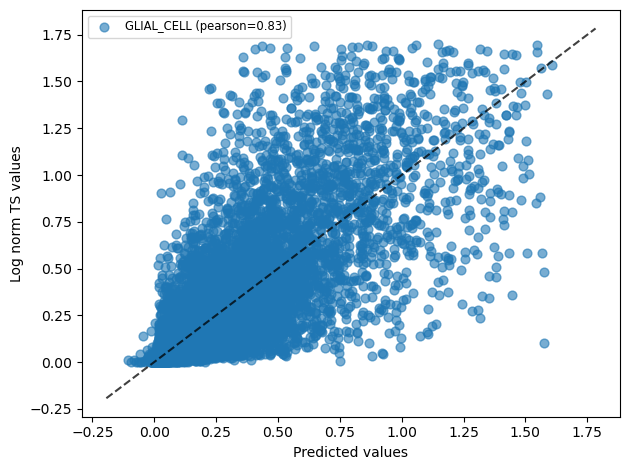

In [5]:
# Unique cell types
cell_types = combined_df['cell_type'].unique()
colors = sns.color_palette("tab10", len(cell_types))

# Loop through each cell type
for i, cell in enumerate(cell_types):
    sub = combined_df[combined_df['cell_type'] == cell]

    # Calculate Spearman correlation
    rho, pval = spearmanr(sub['linear_pred'], sub['log_norm_ts'])
    # Calculate Pearson correlation
    pearson_corr, pval_pearson = pearsonr(sub['linear_pred'], sub['log_norm_ts'])
    print(f"Spearman correlation for {cell}: {rho:.2f} (p-value: {pval:.2e})")
    print(f"Pearson correlation for {cell}: {pearson_corr:.2f} (p-value: {pval_pearson:.2e})")

    # Plot points
    plt.scatter(sub['linear_pred'], sub['log_norm_ts'], label=f"{cell} (pearson={pearson_corr:.2f})", alpha=0.6, s=40, color=colors[i])

# Add reference line (optional)
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(lims, lims, 'k--', alpha=0.75)

# Labels and legend
plt.xlabel("Predicted values")
plt.ylabel("Log norm TS values")

# Labels and legend
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()


Spearman correlation for GLIAL_CELL: 0.93 (p-value: 0.00e+00)
Pearson correlation for GLIAL_CELL: 0.77 (p-value: 0.00e+00)


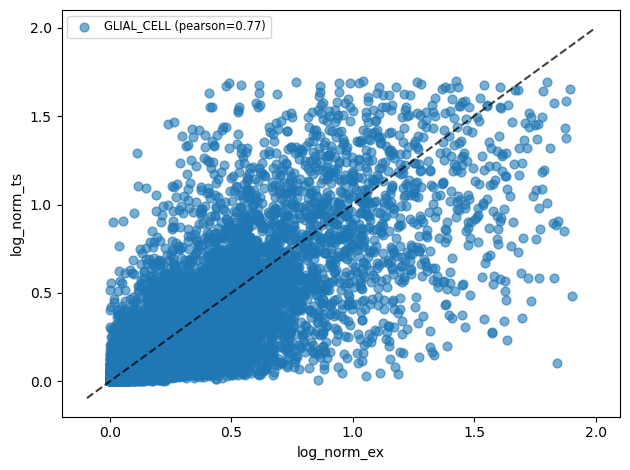

In [6]:
# Loop through each cell type
for i, cell in enumerate(cell_types):
    sub = combined_df[combined_df['cell_type'] == cell]

    # Calculate Spearman correlation
    rho, pval = spearmanr(sub['log_norm_ex'], sub['log_norm_ts'])
    # Calculate Pearson correlation
    pearson_rho, pearson_pval = pearsonr(sub['log_norm_ex'], sub['norm_ts'])
    print(f"Spearman correlation for {cell}: {rho:.2f} (p-value: {pval:.2e})")
    print(f"Pearson correlation for {cell}: {pearson_rho:.2f} (p-value: {pearson_pval:.2e})")
    # Plot points
    plt.scatter(sub['log_norm_ex'], sub['log_norm_ts'], label=f"{cell} (pearson={pearson_rho:.2f})", alpha=0.6, s=40, color=colors[i])

# Add reference line (optional)
lims = [
    np.min([plt.xlim(), plt.ylim()]),  # min of both axes
    np.max([plt.xlim(), plt.ylim()]),  # max of both axes
]
plt.plot(lims, lims, 'k--', alpha=0.75)

# Labels and legend
plt.xlabel("log_norm_ex")
plt.ylabel("log_norm_ts")
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()
